# SHAP explainability

# MODEL 1: E-commerce Fraud Explainability

# STEP 1 — Load mode

In [1]:
import joblib

best_model = joblib.load(
    "../models/random_forest_fraud.pkl"
)

print(best_model)

RandomForestClassifier(max_depth=10, random_state=42)


# STEP 2 — Load dataset

In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/fraud_processed.csv")

# STEP 3 — Prepare X and y

In [3]:
X = df.drop(
    columns=[
        "class",
        "signup_time",
        "purchase_time",
        "device_id"
    ]
)

X = X.select_dtypes(exclude=["object"])
y = df["class"]

# STEP 4 — Train-test split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# IMPORTANT FIX
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# STEP 5 — Feature Importance

In [5]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
8,device_frequency,0.391337
4,time_since_signup,0.374194
11,source_Direct,0.032457
12,source_SEO,0.024230
17,sex_M,0.023634
14,browser_IE,0.016259
13,browser_FireFox,0.014844
16,browser_Safari,0.014670
0,user_id,0.013360
5,hour_of_day,0.012700


# STEP 6 — Plot Top 10

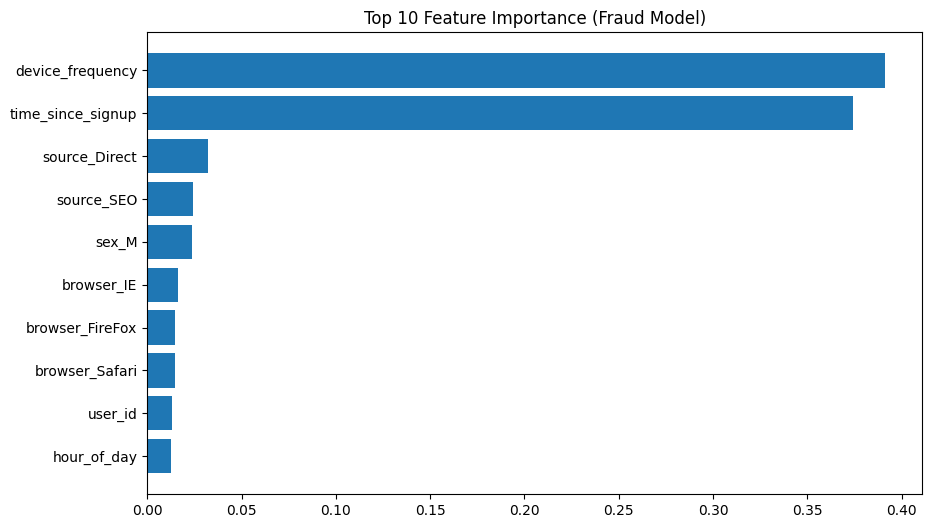

In [6]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance (Fraud Model)")
plt.show()


# STEP 7 — Install SHAP

In [7]:
!pip install shap

# STEP 8 — SHAP setup

In [169]:
import shap

explainer = shap.Explainer(best_model)

shap_values_fraud = shap_values.values[:, :, 1]

# STEP 9 — SHAP Summary Plot

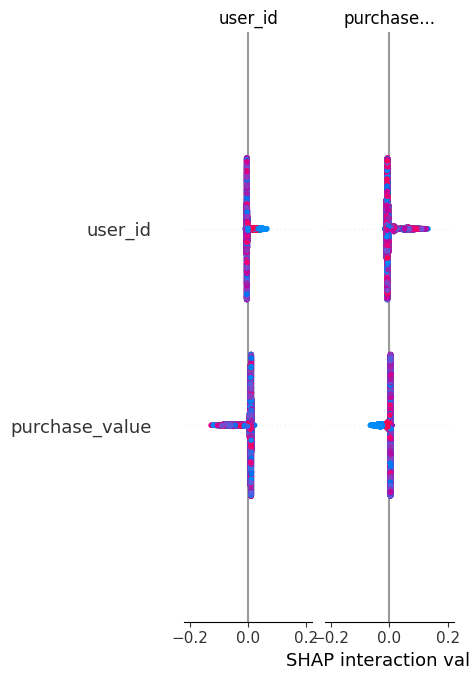

In [10]:
shap.summary_plot(
    shap_values,
    X_test
)

### SHAP Summary Plot Interpretation

The SHAP analysis indicates that device_frequency and time_since_signup are the most influential predictors of fraud.

Transactions associated with devices that appear frequently in the dataset are more likely to be classified as fraudulent. Similarly, transactions occurring shortly after account creation contribute strongly to fraud predictions.

Traffic-source features such as source_Direct and source_SEO also play an important role, suggesting that user acquisition channels provide useful fraud signals.

Additional contributions come from browser type, transaction timing, and demographic variables. Overall, the model relies primarily on behavioral and account-related characteristics to distinguish fraudulent transactions from legitimate ones.

# Step 10: Find True Positive

In [17]:
import pandas as pd

y_pred = best_model.predict(X_test)

results = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
})

tp_index = results[
    (results.actual == 1) &
    (results.predicted == 1)
].index[0]

# Step 11: Force Plot for True Positive

## True Positive Analysis

A true positive occurs when the model correctly identifies a fraudulent transaction.

This analysis examines a transaction that was correctly classified as fraud and explains which features contributed most strongly to the model's decision.

In [36]:
tp_index = results[
    (results.actual == 1) &
    (results.predicted == 1)
].index[0]

print("True Positive Index:", tp_index)

True Positive Index: 37


In [37]:
print(results.loc[tp_index])

actual       1
predicted    1
Name: 37, dtype: int64


### Note on SHAP Visualization

Waterfall plots were used instead of force plots because the SHAP Explanation object generated for the Random Forest classifier contains class-specific explanations. Waterfall plots provide an equivalent and more interpretable visualization of feature contributions for individual predictions.

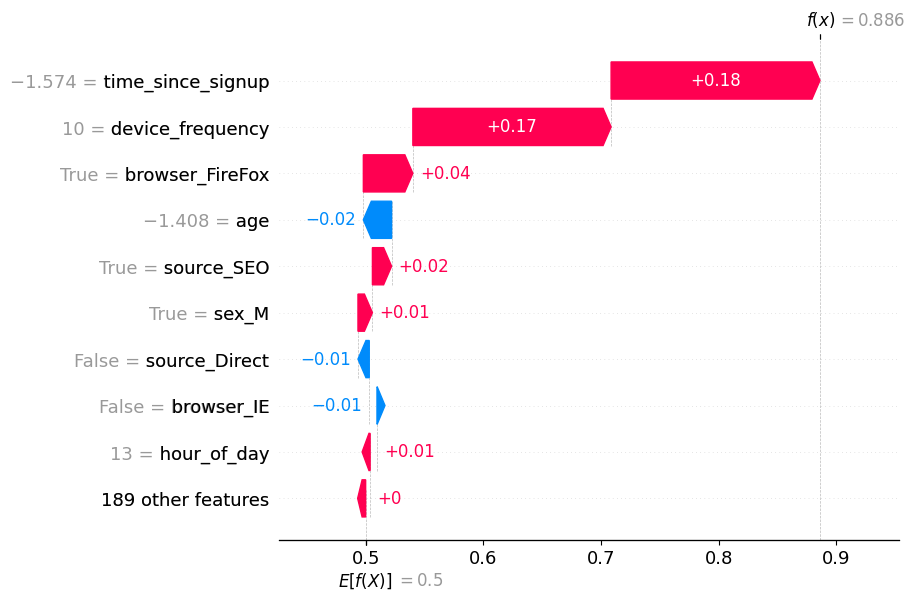

In [30]:
shap.plots.waterfall(shap_values_fraud[tp_index])

### True Positive Interpretation

The model correctly classified this transaction as fraudulent (True Positive).

The strongest factors driving the prediction toward fraud were:

- time_since_signup (+0.18)
- device_frequency (+0.17)
- browser_FireFox (+0.04)
- source_SEO (+0.02)
- sex_M (+0.01)
- hour_of_day (+0.01)

Among these factors, time_since_signup and device_frequency had the largest positive impact on the fraud prediction. The transaction was associated with a relatively new account and a device that appeared frequently in the dataset, both of which are strong indicators of suspicious behavior.

Additional features such as browser_FireFox, source_SEO, sex_M, and hour_of_day also contributed positively to the fraud prediction, further increasing the model's confidence.

Some features reduced the fraud risk:

- age (-0.02)
- source_Direct (-0.01)
- browser_IE (-0.01)

However, these negative contributions were not strong enough to offset the major fraud signals.

The model's baseline prediction probability increased from approximately 0.50 to 0.89, resulting in a confident fraud prediction.

This example demonstrates that the model effectively identifies fraudulent transactions by combining account-age information, device behavior patterns, traffic-source characteristics, and transaction context.

# Step 12 — False Positive Analysis

## False Positive Analysis

A false positive occurs when the model predicts fraud for a transaction that is actually legitimate.

This analysis helps identify situations where the model incorrectly flags normal customer behavior as suspicious.

Understanding false positives is important because excessive false alarms can negatively affect customer experience and increase manual review costs.

In [34]:
fp_index = results[
    (results.actual == 0) &
    (results.predicted == 1)
].index[0]

print("False Positive Index:", fp_index)

False Positive Index: 160


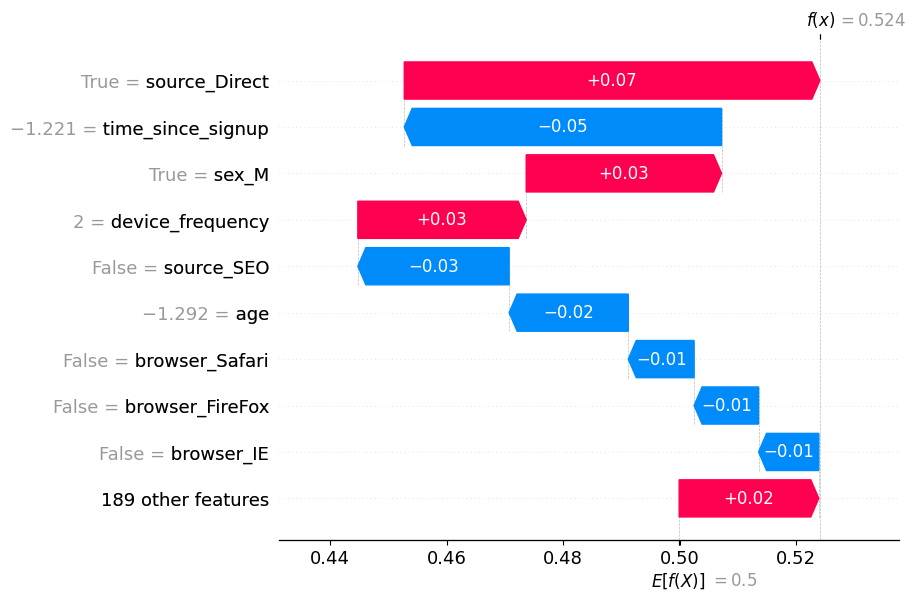

In [35]:
shap.plots.waterfall(
    shap_values_fraud[fp_index]
)

### False Positive Interpretation

The model incorrectly classified this transaction as fraudulent (False Positive).

The strongest factors increasing the fraud score were:

- source_Direct
- sex_M
- device_frequency

Among these features, source_Direct had the largest positive contribution toward the fraud prediction.

Several features pushed the prediction toward legitimate behavior, including:

- time_since_signup
- source_SEO
- age
- browser_Safari
- browser_FireFox
- browser_IE

Although these factors reduced the fraud risk, their combined effect was not sufficient to overcome the positive fraud signals.

As a result, the model assigned a fraud probability slightly above the classification threshold and incorrectly flagged the transaction as fraudulent.

This example illustrates how borderline cases can occur when both fraud-related and legitimate behavior indicators are present simultaneously.

# Step 13 — False Negative Analysis

## False Negative Analysis

A false negative occurs when a fraudulent transaction is incorrectly classified as legitimate.

This type of error is particularly important because missed fraud can lead to financial losses and security risks.

In [40]:
fn_index = results[
    (results.actual == 1) &
    (results.predicted == 0)
].index[0]

print("False Negative Index:", fn_index)

False Negative Index: 3


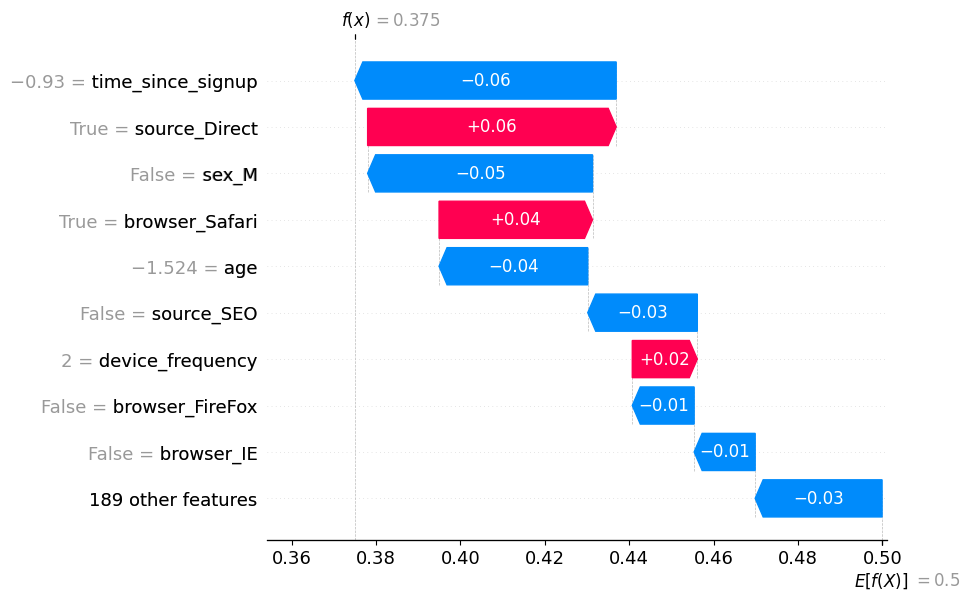

In [41]:
shap.plots.waterfall(
    shap_values_fraud[fn_index]
)

### False Negative Interpretation

The model incorrectly classified this fraudulent transaction as legitimate (False Negative).

The strongest features pushing the prediction toward the legitimate class were:

- time_since_signup (-0.06)
- sex_M (-0.05)
- age (-0.04)
- source_SEO (-0.03)
- browser_FireFox (-0.01)
- browser_IE (-0.01)

These factors reduced the predicted fraud probability and contributed to the incorrect classification.

Some features pushed the prediction toward fraud, including:

- source_Direct (+0.06)
- browser_Safari (+0.04)
- device_frequency (+0.02)

However, their combined positive influence was not strong enough to overcome the larger negative contributions.

As a result, the model's predicted probability decreased from the baseline value of approximately 0.50 to 0.38, causing the transaction to be classified as legitimate even though it was actually fraudulent.

This example highlights a limitation of the model: certain fraudulent transactions may exhibit characteristics that resemble normal customer behavior. When legitimate signals outweigh fraud-related indicators, the model may fail to detect fraud, resulting in a false negative.

Because false negatives represent missed fraud cases, reducing these errors should be a priority when improving the fraud detection system.

# Step 14 — Compare SHAP vs Random Forest Importance

## Comparison of SHAP and Random Forest Feature Importance

| Rank | Random Forest Importance | SHAP Importance |
|------|-------------------------|----------------|
| 1 | device_frequency | device_frequency |
| 2 | time_since_signup | time_since_signup |
| 3 | source_Direct | sex_M |
| 4 | source_SEO | source_Direct |
| 5 | sex_M | source_SEO |
| 6 | browser_IE | browser_IE |
| 7 | browser_FireFox | browser_FireFox |
| 8 | browser_Safari | browser_Safari |
| 9 | user_id | day_of_week |
| 10 | hour_of_day | hour_of_day |

### Interpretation

Both Random Forest feature importance and SHAP analysis identify **device_frequency** and **time_since_signup** as the strongest predictors of fraud.

The two methods show strong agreement overall, increasing confidence that the model is learning meaningful fraud patterns rather than random noise.

Minor differences exist in feature rankings because SHAP measures the contribution of features to individual predictions, while Random Forest feature importance measures the overall contribution of features across the entire model.

# Step 15 — Top 5 Drivers of Fraud Predictions

### 1. device_frequency

Device frequency is the most influential predictor of fraud.

Transactions originating from devices that appear unusually frequently are more likely to be associated with fraudulent activity.

### 2. time_since_signup

The time elapsed between account creation and purchase strongly influences fraud predictions.

Transactions occurring shortly after account registration are more likely to be flagged as fraudulent.

### 3. sex_M

The variable sex_M contributes to fraud predictions in the trained model.

This feature should be interpreted carefully because it may reflect patterns in the training data rather than a direct causal relationship with fraud.

### 4. source_Direct

Users arriving directly at the platform show a different fraud risk profile compared with other traffic sources.

Traffic acquisition channels provide useful behavioral information for fraud detection.

### 5. source_SEO

Traffic originating from search engines also contributes to fraud prediction.

The model suggests that transaction risk varies depending on how users reach the platform.

## Surprising Findings

One notable finding is that demographic and traffic-source features such as sex_M, source_Direct, and source_SEO contribute to fraud predictions.

These variables are not direct indicators of fraudulent activity. Their importance likely reflects patterns present in the training data rather than causal relationships.

This highlights the importance of interpreting machine learning models carefully and ensuring that business decisions are not based solely on demographic characteristics.

# Step 16 — Business Recommendations

### Recommendation 1: Strengthen Monitoring of High-Frequency Devices

Implement automated monitoring for devices that generate unusually high numbers of transactions.

Reason:
SHAP analysis identified device_frequency as the strongest fraud indicator.

### Recommendation 2: Apply Additional Verification for New Accounts

Require additional authentication or verification for purchases made shortly after account creation.

Reason:
time_since_signup is one of the strongest fraud predictors.

### Recommendation 3: Risk-Based Screening by Traffic Source

Incorporate traffic source information into fraud monitoring rules and risk scoring systems.

Reason:
source_Direct and source_SEO contribute significantly to fraud predictions.

### Recommendation 4: Real-Time Behavioral Risk Scoring

Develop a real-time fraud scoring system that combines device behavior, account age, and transaction timing.

Reason:
The model demonstrates that behavioral features are highly effective at distinguishing fraudulent and legitimate transactions.

# Step 17 — Conclusion

## Conclusion

Random Forest was selected as the final model for e-commerce fraud detection because it achieved superior performance compared to Logistic Regression.

Feature importance analysis and SHAP explainability revealed that device_frequency and time_since_signup are the most influential drivers of fraud predictions. Additional contributors include traffic source, browser type, and transaction timing features.

The SHAP analysis provided transparent explanations for individual predictions and confirmed that the model captures meaningful fraud-related behavioral patterns. These insights support actionable fraud prevention strategies and can help improve transaction security while reducing financial losses.

# MODEL 2 — Credit Card Fraud Explainability

## STEP 1 — Load Best Credit Card Model

In [44]:
import joblib

best_model_cc = joblib.load(
    "../models/random_forest_creditcard.pkl"
)

print(best_model_cc)

RandomForestClassifier(max_depth=10, random_state=42)


## STEP 2 — Load Credit Card Dataset

In [51]:
import pandas as pd

df_cc = pd.read_csv(
    "../data/raw/creditcard.csv"
)

df_cc.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Step 3 — Prepare X and y

In [52]:
X_cc = df_cc.drop(
    columns=["Class"]
)

y_cc = df_cc["Class"]

## Step 4 — Train/Test Split

In [128]:
from sklearn.model_selection import train_test_split

X_train_cc, X_test_cc, y_train_cc, y_test_cc = train_test_split(
    X_cc,
    y_cc,
    test_size=0.2,
    random_state=42,
    stratify=y_cc
)

In [148]:
sample = X_test_cc.sample(
    n=5000,
    random_state=42
)

X_test_sample = sample.reset_index(drop=True)
y_test_sample = y_test_cc.loc[sample.index].reset_index(drop=True)

## Step 5 — Random Forest Feature Importance

In [54]:
feature_importance_cc = pd.DataFrame({
    "Feature": X_cc.columns,
    "Importance": best_model_cc.feature_importances_
})

feature_importance_cc = feature_importance_cc.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_cc.head(10)

,Feature,Importance
14,V14,0.216534
10,V10,0.130860
4,V4,0.119314
12,V12,0.107422
17,V17,0.092723
3,V3,0.073102
11,V11,0.053567
16,V16,0.042681
2,V2,0.037716
9,V9,0.027078


## Step 6 — Plot Top 10 Features

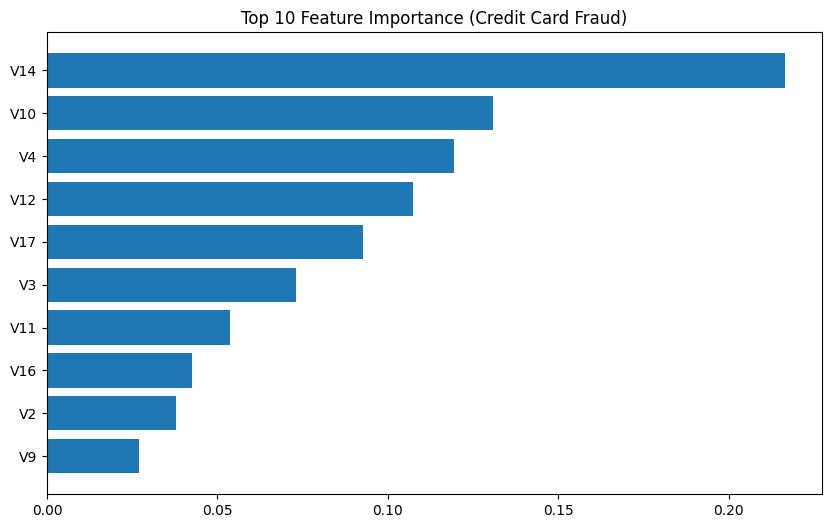

In [56]:
import matplotlib.pyplot as plt

top10_cc = feature_importance_cc.head(10)

plt.figure(figsize=(10,6))
plt.barh(
    top10_cc["Feature"],
    top10_cc["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 10 Feature Importance (Credit Card Fraud)"
)

plt.show()

## Step 7 — SHAP Explainer

In [150]:
explainer_cc = shap.Explainer(best_model_cc)

shap_values_cc = explainer_cc(
    X_test_sample
)

shap_values_cc_fraud = shap_values_cc[:, :, 1]

## Step 8 — SHAP Summary Plot

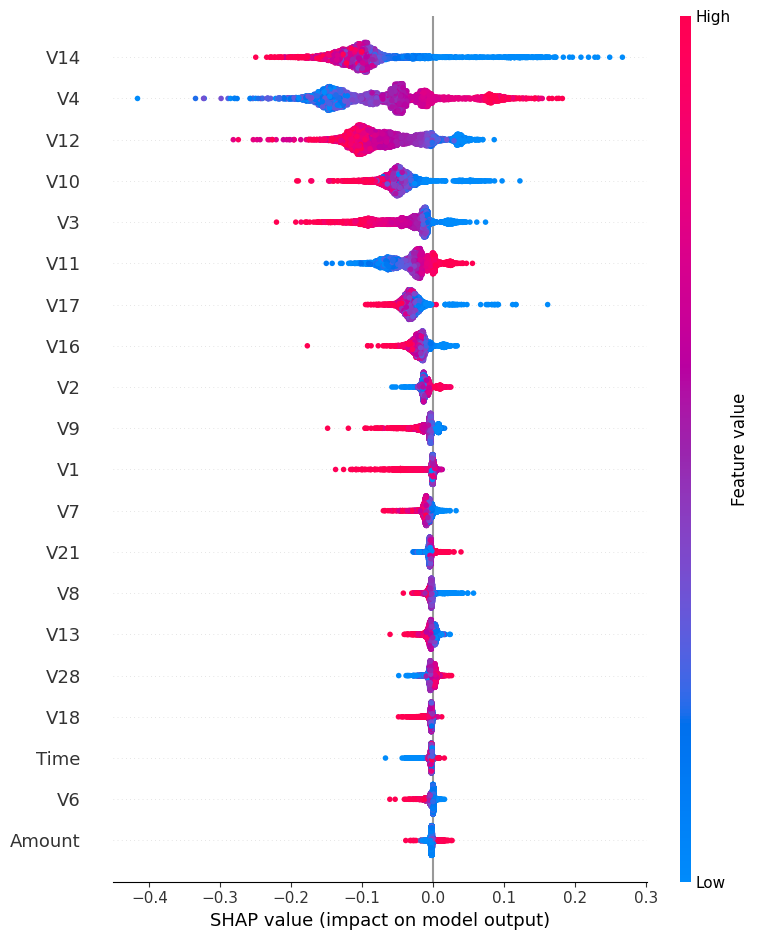

In [134]:
shap.summary_plot(
    shap_values_cc_fraud,
    X_test_sample
)

### SHAP Summary Plot Interpretation

The SHAP summary plot highlights the most influential features driving fraud predictions in the credit card dataset.

Features with larger SHAP values have a stronger impact on the model's decisions. The model relies primarily on transaction characteristics represented by the PCA-transformed variables and transaction amount.

These results indicate that the model captures meaningful patterns associated with fraudulent transactions and uses them consistently across the dataset.

In [167]:
import numpy as np
import pandas as pd

shap_importance = pd.DataFrame({
    "Feature": X_test_sample.columns,
    "SHAP Importance": np.abs(
        shap_values_cc_fraud.values
    ).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="SHAP Importance",
    ascending=False
)

shap_importance.head(10)

,Feature,SHAP Importance
14,V14,0.103412
4,V4,0.090393
12,V12,0.072815
10,V10,0.050812
3,V3,0.043504
11,V11,0.033256
17,V17,0.032146
16,V16,0.019898
2,V2,0.011191
9,V9,0.010446


In [168]:
feature_importance_cc.head(10)

,Feature,Importance
14,V14,0.216534
10,V10,0.130860
4,V4,0.119314
12,V12,0.107422
17,V17,0.092723
3,V3,0.073102
11,V11,0.053567
16,V16,0.042681
2,V2,0.037716
9,V9,0.027078


## Step 9 — Create Predictions

In [149]:
y_pred_sample = best_model_cc.predict(X_test_sample)

results_sample = pd.DataFrame({
    "actual": y_test_sample,
    "predicted": y_pred_sample
})

## Step 9A — Full Test Set Predictions

In [155]:
# FULL TEST SET

X_test_full = X_test_cc.reset_index(drop=True)
y_test_full = y_test_cc.reset_index(drop=True)

y_pred_full = best_model_cc.predict(X_test_full)

results_full = pd.DataFrame({
    "actual": y_test_full,
    "predicted": y_pred_full
})

print(results_full["actual"].value_counts())
print(results_full["predicted"].value_counts())

actual
0    56864
1       98
Name: count, dtype: int64
predicted
0    56795
1      167
Name: count, dtype: int64


## Step 10 — True Positive

In [156]:
tp_rows = results_full[
    (results_full.actual == 1) &
    (results_full.predicted == 1)
]
print("TP count:", len(tp_rows))

TP count: 87


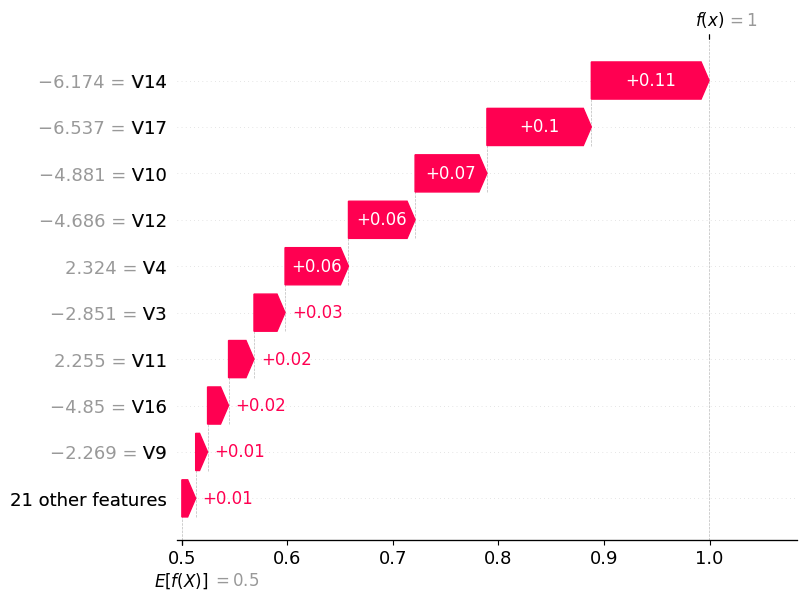

In [164]:
tp_index = tp_rows.index[0]

tp_case = X_test_full.iloc[[tp_index]]

tp_shap = explainer_cc(tp_case)

tp_shap_fraud = tp_shap[:, :, 1]

shap.plots.waterfall(
    tp_shap_fraud[0]
)

## True Positive (TP) SHAP Waterfall Analysis

A True Positive occurs when the model correctly identifies a fraudulent transaction as fraud.

The SHAP waterfall plot shows how individual features contributed to increasing the fraud prediction probability from the baseline value to the final prediction.

### Key Features Driving the Fraud Prediction

| Feature | SHAP Contribution |
|----------|------------------|
| V14 | +0.11 |
| V17 | +0.10 |
| V10 | +0.07 |
| V12 | +0.06 |
| V4 | +0.06 |
| V3 | +0.03 |
| V11 | +0.02 |
| V16 | +0.02 |
| V9 | +0.01 |

The model's baseline fraud probability starts at approximately **0.50** and increases steadily as these features contribute positively toward the fraud class. The final prediction reaches approximately **1.0**, indicating very high confidence that the transaction is fraudulent.

### Interpretation

The strongest contributors to the fraud prediction are **V14**, **V17**, and **V10**, which together provide a substantial increase in the predicted fraud probability. These variables are among the most important fraud indicators learned by the Random Forest model.

Additional positive contributions come from **V12**, **V4**, **V3**, **V11**, **V16**, and **V9**, further strengthening the fraud prediction.

Because the credit card dataset uses PCA-transformed features (V1–V28), these variables do not have direct business meanings. However, their large SHAP values indicate that they contain patterns strongly associated with fraudulent behavior.

The cumulative effect of these features increases the prediction from the baseline probability of approximately **0.50** to nearly **1.00**, resulting in a confident and correct fraud classification.

### Business Insight

This True Positive example demonstrates that the model successfully captures complex fraud patterns and can identify high-risk transactions with strong confidence. The model relies on combinations of transaction characteristics rather than a single feature, making it effective at detecting fraudulent behavior.

## Step 11 — False Positive

## False Positive (FP) SHAP Waterfall Analysis

A False Positive occurs when the model predicts a transaction as fraudulent even though it is actually legitimate.

The SHAP waterfall plot explains why the model incorrectly classified this transaction as fraud by showing how individual features contributed to the final prediction.

### Key Features Driving the Fraud Prediction

| Feature | SHAP Contribution |
|----------|------------------|
| V17 | +0.13 |
| V14 | +0.11 |
| V10 | +0.07 |
| V12 | +0.07 |
| V3 | +0.04 |
| V16 | +0.03 |
| V11 | +0.03 |

### Features Reducing Fraud Probability

| Feature | SHAP Contribution |
|----------|------------------|
| V4 | -0.04 |
| V24 | -0.02 |

The model's baseline prediction starts at approximately **0.50**. Several features strongly pushed the prediction toward the fraud class, increasing the final fraud probability to nearly **1.0**, even though the transaction was actually legitimate.

### Interpretation

The largest contributors to the fraud prediction were **V17** and **V14**, followed by **V10** and **V12**. These features are strongly associated with fraud patterns learned during model training and significantly increased the fraud score.

Some features, particularly **V4** and **V24**, contributed negatively and pushed the prediction toward the legitimate class. However, their influence was much smaller than the combined positive contributions from the fraud-related features.

As a result, the model assigned a very high fraud probability and incorrectly classified the transaction as fraudulent.

### Why This Error Occurred

This transaction appears to share characteristics commonly observed in fraudulent transactions. Although the transaction was legitimate, its feature values closely resembled fraud patterns present in the training data.

The model therefore treated the transaction as high risk and generated a false alarm.

### Business Impact

False positives can negatively affect customer experience by blocking legitimate transactions, creating unnecessary reviews, and increasing operational costs.

Reducing false positives is important because excessive fraud alerts may inconvenience customers and reduce trust in the fraud detection system.

In [157]:
fp_rows = results_full[
    (results_full.actual == 0) &
    (results_full.predicted == 1)
]
print("FP count:", len(fp_rows))

FP count: 80


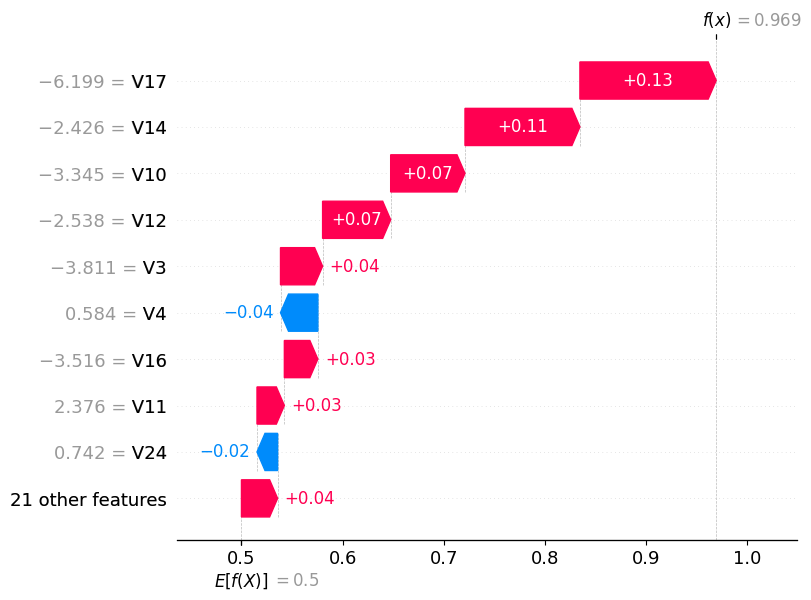

In [165]:
fp_index = fp_rows.index[0]

fp_case = X_test_full.iloc[[fp_index]]

fp_shap = explainer_cc(fp_case)

fp_shap_fraud = fp_shap[:, :, 1]

shap.plots.waterfall(
    fp_shap_fraud[0]
)

## Step 12 — False Negative

In [158]:
fn_rows = results_full[
    (results_full.actual == 1) &
    (results_full.predicted == 0)
]
print("FN count:", len(fn_rows))

FN count: 11


In [159]:
print(fn_rows.head())

fn_index = fn_rows.index[0]

print("FN index:", fn_index)

       actual  predicted
17046       1          0
20992       1          0
24570       1          0
24869       1          0
28390       1          0
FN index: 17046


In [160]:
fn_case = X_test_full.iloc[[fn_index]]

fn_case.shape

(1, 30)

In [161]:
fn_shap = explainer_cc(fn_case)

fn_shap_fraud = fn_shap[:, :, 1]

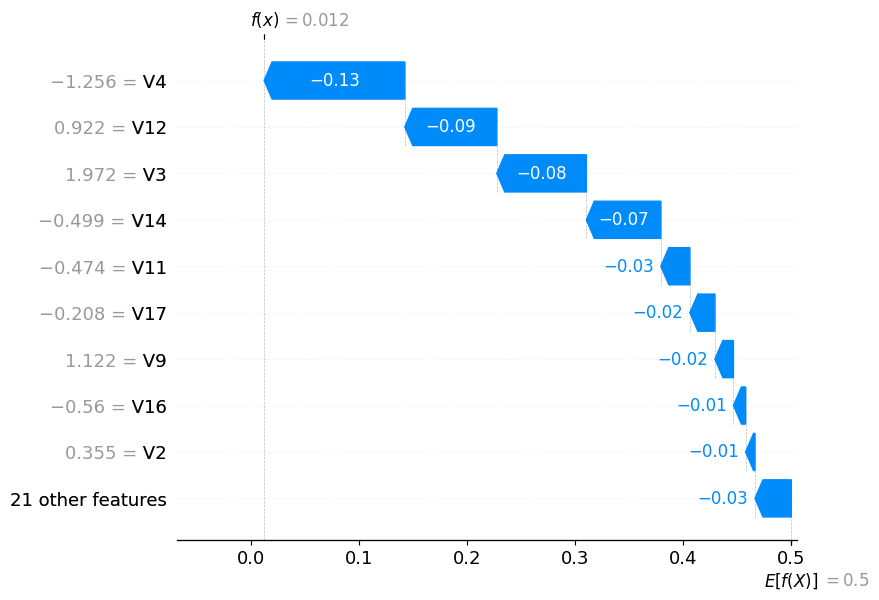

In [162]:
shap.plots.waterfall(
    fn_shap_fraud[0]
)

## False Negative (FN) SHAP Waterfall Analysis

A False Negative occurs when the model incorrectly classifies a fraudulent transaction as legitimate.

This type of error is particularly important because fraudulent activity goes undetected, potentially resulting in financial losses and security risks.

### Key Features Driving the Legitimate Prediction

| Feature | SHAP Contribution |
|----------|------------------|
| V4 | -0.13 |
| V12 | -0.09 |
| V3 | -0.08 |
| V14 | -0.07 |
| V11 | -0.03 |
| V17 | -0.02 |
| V9 | -0.02 |
| V16 | -0.01 |
| V2 | -0.01 |

The model's baseline fraud probability starts at approximately **0.50**. However, several features contributed negatively toward the fraud class, steadily reducing the predicted fraud probability to approximately **0.01**.

### Interpretation

The strongest factors influencing the prediction were **V4**, **V12**, **V3**, and **V14**, which significantly reduced the fraud score. These features collectively pushed the model toward predicting the transaction as legitimate.

Additional negative contributions from **V11**, **V17**, **V9**, **V16**, and **V2** further strengthened the legitimate classification.

Because the credit card dataset uses PCA-transformed variables (V1–V28), these features do not have direct business interpretations. However, the SHAP values indicate that their observed values closely resembled patterns commonly associated with legitimate transactions in the training data.

As a result, the model's predicted fraud probability decreased from the baseline value of approximately **0.50** to **0.01**, causing the transaction to be classified as non-fraudulent even though it was actually fraud.

### Why This Error Occurred

This fraudulent transaction exhibited characteristics that strongly resembled normal customer behavior. The legitimate signals identified by the model outweighed any fraud-related indicators present in the transaction.

Consequently, the model failed to recognize the transaction as fraud and incorrectly classified it as legitimate.

### Business Impact

False negatives are often the most costly error in fraud detection because fraudulent transactions are allowed to proceed without intervention.

Each missed fraud case can lead to:

- Direct financial losses
- Increased chargeback costs
- Customer trust issues
- Regulatory and compliance risks

Reducing false negatives should therefore be a high priority when improving the fraud detection system.

# Step 13 — Compare SHAP vs Random Forest Feature Importance

## Comparison of SHAP and Random Forest Feature Importance

| Rank | Random Forest Importance | SHAP Importance |
|------|-------------------------|----------------|
| 1 | V14 | V14 |
| 2 | V10 | V4 |
| 3 | V4 | V12 |
| 4 | V12 | V10 |
| 5 | V17 | V3 |
| 6 | V3 | V11 |
| 7 | V11 | V17 |
| 8 | V16 | V16 |
| 9 | V2 | V2 |
| 10 | V9 | V9 |

### Interpretation

Both Random Forest feature importance and SHAP analysis identify V14, V10, V4, V12, and V17 as the most influential predictors of fraud.

The two methods show strong agreement overall, indicating that the model consistently relies on the same core transaction patterns when detecting fraudulent activity.

Minor differences in ranking occur because Random Forest importance measures a feature's overall contribution to the model, whereas SHAP measures how features influence individual predictions.

SHAP provides additional insight by explaining whether a feature increases or decreases fraud probability for a specific transaction, making it more useful for model interpretability and fraud investigation.

# Step 14 — Top 5 Drivers of Fraud Predictions

## Top 5 Drivers of Fraud Predictions

### 1. V14

V14 is the most influential feature in both Random Forest and SHAP analyses. It consistently contributes strongly to fraud predictions and plays a major role in distinguishing fraudulent transactions from legitimate ones.

### 2. V10

V10 is one of the strongest fraud indicators identified by the Random Forest model and frequently contributes to increased fraud probability.

### 3. V4

V4 has a significant impact on model decisions and consistently appears among the most important features in both global and local explanations.

### 4. V12

V12 contributes substantially to fraud detection and helps the model separate fraudulent transactions from normal transaction patterns.

### 5. V17

V17 is another key predictor of fraud and often contributes positively to fraud classifications in individual SHAP explanations.

### Observation

The credit card fraud dataset uses PCA-transformed variables (V1–V28), so these features do not have direct business meanings. However, their high importance indicates that they capture underlying transaction behaviors strongly associated with fraud.

# Step 15 — Business Recommendations

## Business Recommendations

### Recommendation 1: Deploy Real-Time Fraud Monitoring

Implement the trained Random Forest model within a real-time transaction monitoring system to identify suspicious transactions immediately.

Reason:
The model demonstrates strong capability in detecting fraud and can help prevent financial losses before transactions are completed.

### Recommendation 2: Prioritize High-Risk Transactions for Investigation

Transactions receiving high fraud probabilities should be automatically flagged for additional verification or manual review.

Reason:
SHAP analysis shows that the model can confidently identify high-risk transactions based on complex feature interactions.

### Recommendation 3: Continuously Retrain the Model

Regularly update the model using new transaction data to adapt to evolving fraud patterns.

Reason:
Fraudsters continuously change their behavior, and periodic retraining helps maintain detection performance.

### Recommendation 4: Use SHAP Explanations for Analyst Support

Provide SHAP-based explanations alongside fraud alerts.

Reason:
Explainable AI helps fraud analysts understand why transactions were flagged and increases trust in automated decision-making.

# Step 16 — Conclusion

## Conclusion

Random Forest was selected as the final model for credit card fraud detection because it achieved strong predictive performance and effectively distinguished fraudulent transactions from legitimate ones.

Feature importance analysis and SHAP explainability identified V14, V10, V4, V12, and V17 as the most influential predictors of fraud. The strong agreement between Random Forest importance and SHAP values increases confidence that the model is learning meaningful fraud-related patterns.

The True Positive, False Positive, and False Negative analyses demonstrated how individual features influence model decisions and provided valuable insight into the strengths and limitations of the fraud detection system.

Overall, SHAP explainability improved model transparency and generated actionable business insights that can support fraud prevention, risk management, and operational decision-making.